# Modular cost-to-go for distributed MPC
### Two inventories sharing a limited capacity
- Dinesh Krishnamoorthy (dinesh.krishnamoorthy@ntnu.no)

**Setup.** Two independent inventories, each with its own demand:

$$x_{i,k+1} \;=\; x_{i,k} + u_{i,k} - d_{i,k}, \qquad 0 \le u_{i,k} \le \bar u_i$$

$x_i$ is the inventory level (positive = stock on hand, negative = backlog) and
is **unconstrained**; $u_i$ is the replenishment order; $d_i$ is demand, which we
do not control. We want to drive every $x_i$ to zero.

The two inventories have decoupled dynamics and separable costs. They are tied together only by a shared supplier, or production capacity:

$$u_{1,k} + u_{2,k} \;\le\; \bar U$$

**Why the cost-to-go is coupled.** If the prediction horizon is shortened and a cost-to-go is appended as a terminal cost, that cost-to-go cannot be separable. When inventory 2 is deeply backlogged, it will claim capacity over the coming steps, which raises the future cost of inventory 1. The cost-to-go of one inventory therefore depends on the state of the other.

**The idea.** Anchored at the target $(0,0)$, the anchored ANOVA decomposition splits this coupled cost-to-go exactly:

$$V^\star(x_1,x_2) \;=\; \underbrace{V_1(x_1)}_{\text{inventory 1 alone}}
+ \underbrace{V_2(x_2)}_{\text{inventory 2 alone}}
+ \underbrace{V_{12}(x_1,x_2)}_{\text{price of sharing the capacity}}$$

This notebook shows how each module is identified, and how the modules are used in a distributed one-step MPC.

NB!  $V_0 = V^\star(0,0)$ is a constant that does not affect decisions. 

This notebook does the following:
1. Builds a long-horizon centralised *expert* MPC (the ideal baseline).
2. Learn $\hat V_{\text{central}}$ from the expert MPC and use it in a **1-step centralised** MPC. This demonstrates that the cost-to-go is coupled. 
3. Single-agent experts that ignore the shared capacity; learn $\hat V_1,\hat V_2$.
4. Verfiy the anchored-ANOVA structure on the anchor slices (the **key hypothesis** of my proposal).
5. Learn the coupling term $\hat V_{12}$ from expert data (through structured _value identification_).
6. Verify **modular reconstruction** $\hat V_1+\hat V_2+\hat V_{12} \approx V^\star$ 

In [1]:
import time
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy.linalg import solve_discrete_are
from scipy.interpolate import RBFInterpolator

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True})

## 0. Problem data and the deviation coordinates

At the setpoint $x_i = 0$ the order must exactly cover demand, $u_i = d_i$. It is
cleaner to work in **deviation** coordinates

$$\tilde u_i \;=\; u_i - d_i \qquad\Longrightarrow\qquad x_i^+ = x_i + \tilde u_i,$$

so each inventory is a plain integrator driven by the *excess* order. The
constraints become

$$-d_i \le \tilde u_i \le \bar u_i - d_i,
\qquad \tilde u_1 + \tilde u_2 \;\le\; \underbrace{\bar U - d_1 - d_2}_{=:S},$$

where $S$ is the **spare capacity**: how much the two of them can *jointly*
order above their combined demand. Note the coupling is one-sided — they fight
only when both are trying to rebuild stock at the same time.

NB! Agent 2's shortages are costed 3× more heavily than agent 1's, so who gets the
spare capacity is a non-trivial decision, and not a symmetric split. 

In [2]:
d = np.array([2.0, 3.0])          # demand rates (known, constant nominal)
umax = np.array([5.0, 6.0])       # individual order caps
U_SHARED = 8.0                    # shared capacity: u1 + u2 <= U_SHARED
q = np.array([1.0, 3.0])          # inventory deviation cost (agent 2 hurts more)
r = np.array([0.1, 0.1])          # order-smoothing cost
N_EXP = 30                        # expert horizon

S = U_SHARED - d.sum()            # spare capacity in deviation coordinates
lo = -d                           # u_i >= 0      ->  utilde_i >= -d_i
hi = umax - d                     # u_i <= umax_i ->  utilde_i <= umax_i - d_i

# scalar Riccati for the integrator x+ = x + utilde, cost q x^2 + r utilde^2
Ploc = np.array([float(np.squeeze(solve_discrete_are(
    np.array([[1.0]]), np.array([[1.0]]), np.array([[q[i]]]), np.array([[r[i]]]))))
    for i in range(2)])

print(f"demand           d = {d}")
print(f"order caps    umax = {umax}   shared capacity U = {U_SHARED}")
print(f"deviation bounds  : utilde_1 in [{lo[0]:.1f}, {hi[0]:.1f}], "
      f"utilde_2 in [{lo[1]:.1f}, {hi[1]:.1f}]")
print(f"spare capacity  S = {S:.1f}   (both want up to "
      f"{hi[0]:.1f} + {hi[1]:.1f} = {hi.sum():.1f} -> they must share)")
print(f"local terminal weights P = {Ploc}")

demand           d = [2. 3.]
order caps    umax = [5. 6.]   shared capacity U = 8.0
deviation bounds  : utilde_1 in [-2.0, 3.0], utilde_2 in [-3.0, 3.0]
spare capacity  S = 3.0   (both want up to 3.0 + 3.0 = 6.0 -> they must share)
local terminal weights P = [1.0916 3.0969]


## 1. The centralised expert - A long-horizon centralized MPC 

In [3]:
def build_central(N=N_EXP):
    x0 = cp.Parameter(2)
    X = cp.Variable((2, N + 1)); U = cp.Variable((2, N))
    cost = (cp.sum(cp.multiply(q[:, None], cp.square(X[:, :N])))
            + cp.sum(cp.multiply(r[:, None], cp.square(U)))
            + cp.sum(cp.multiply(Ploc, cp.square(X[:, N]))))
    con = [X[:, 0] == x0, X[:, 1:] == X[:, :N] + U,
           U >= lo[:, None], U <= hi[:, None],
           cp.sum(U, axis=0) <= S]                       # <-- the coupling
    prob = cp.Problem(cp.Minimize(cost), con)

    def V(x, want_u=False):
        x0.value = np.asarray(x, float).ravel()
        try:
            prob.solve(solver=cp.CLARABEL)
        except Exception:
            return (np.nan, None) if want_u else np.nan
        if prob.status not in ("optimal", "optimal_inaccurate"):
            return (np.nan, None) if want_u else np.nan
        return (prob.value, U[:, 0].value.copy()) if want_u else prob.value
    return V


V_expert = build_central()
V_expert([-8.0, -9.0])                      # warm up the compiled problem
t0 = time.time(); v = V_expert([-8.0, -9.0])
print(f"V*(-8, -9) = {v:.4f}   ({1000*(time.time()-t0):.1f} ms per solve)")

V*(-8, -9) = 643.4039   (0.9 ms per solve)


In [4]:
def stage_cost(x, ut):
    return float(np.sum(q * np.asarray(x) ** 2) + np.sum(r * np.asarray(ut) ** 2))


def rollout(x0, policy, T=40):
    x = np.array(x0, float)
    traj, us, tot = [x.copy()], [], 0.0
    for _ in range(T):
        ut = policy(x)
        if ut is None or not np.all(np.isfinite(ut)):
            return np.inf, np.array(traj), np.array(us)
        ut = np.asarray(ut, float)
        if ut.sum() > S + 1e-6 or np.any(ut < lo - 1e-6) or np.any(ut > hi + 1e-6):
            return np.inf, np.array(traj), np.array(us)   # constraint violated
        tot += stage_cost(x, ut)
        x = x + ut
        traj.append(x.copy()); us.append(ut.copy())
    return tot + float(np.sum(Ploc * x ** 2)), np.array(traj), np.array(us)


expert_policy = lambda x: V_expert(x, want_u=True)[1]
print(f"{'x0':>16s} {'open-loop V*':>13s} {'realised':>11s} {'rel.diff':>10s}")
for x0 in ([-8.0, -9.0], [-10.0, 4.0], [3.0, -7.0], [-4.0, -4.0]):
    vo = V_expert(x0)
    vr, _, _ = rollout(x0, expert_policy)
    print(f"{str(x0):>16s} {vo:13.4f} {vr:11.4f} {abs(vo-vr)/vo:10.2e}")

              x0  open-loop V*    realised   rel.diff
    [-8.0, -9.0]      643.4039    643.4039   2.81e-10
    [-10.0, 4.0]      220.7885    220.7885   1.85e-11
     [3.0, -7.0]      210.3885    210.3885   7.51e-13
    [-4.0, -4.0]       87.2686     87.2686   5.97e-12


## 2. Learn the centralised cost-to-go

- Sampling is uniform over an operating box.
- Fit a Radial basis function network 


In [5]:
XBOX = 14.0            # sample over [-XBOX, XBOX]^2 (states are unconstrained)
XOP = 10.0             # closed loops start inside [-XOP, XOP]^2


def sample_joint(n, seed):
    rg = np.random.default_rng(seed)
    return rg.uniform(-XBOX, XBOX, (n, 2))


def query(S_):
    V = np.array([V_expert(s) for s in S_])
    ok = np.isfinite(V)
    return S_[ok], V[ok]


t0 = time.time()
gx = np.linspace(-XBOX, XBOX, 29)
GX, GY = np.meshgrid(gx, gx)
S_grid = np.column_stack([GX.ravel(), GY.ravel()])
S_tr, V_tr = query(np.vstack([S_grid, sample_joint(700, 1)]))
S_te, V_te = query(sample_joint(600, 99))
print(f"expert queries: {len(S_tr)+len(S_te)} in {time.time()-t0:.1f} s")
print(f"train {len(S_tr)}, test {len(S_te)}    V* range {V_tr.min():.2f} .. {V_tr.max():.1f}")

rbf_central = RBFInterpolator(S_tr / XBOX, V_tr, kernel="thin_plate_spline",
                              smoothing=1e-8, degree=2)
V_central_hat = lambda X: rbf_central(np.atleast_2d(X) / XBOX)
e = np.abs(V_central_hat(S_te) - V_te) / np.maximum(V_te, 1e-9)
print(f"\nmonolithic fit: median rel.err {np.median(e):.2e}   "
      f"90th {np.percentile(e,90):.2e}   max {e.max():.2e}")

expert queries: 2141 in 1.6 s
train 1541, test 600    V* range 0.00 .. 2451.3

monolithic fit: median rel.err 8.39e-05   90th 6.71e-04   max 6.29e-03


## 3. Single-agent experts, ignoring the shared capacity

Each inventory now solves **its own** MPC with only its own order bounds. It
does not know the other exists. This is what an agent can learn alone. Again we sue RBF networks to learn the local cost-to-go. 

This generates two local RBF networks that each agent learn by itself. 

In [6]:
def build_local(i, N=N_EXP):
    x0 = cp.Parameter(1)
    X = cp.Variable(N + 1); U = cp.Variable(N)
    cost = (q[i] * cp.sum_squares(X[:N]) + r[i] * cp.sum_squares(U)
            + Ploc[i] * cp.square(X[N]))
    con = [X[0] == x0[0], X[1:] == X[:N] + U, U >= lo[i], U <= hi[i]]
    prob = cp.Problem(cp.Minimize(cost), con)

    def V(x, want_u=False):
        x0.value = np.array([float(np.squeeze(x))])
        try:
            prob.solve(solver=cp.CLARABEL)
        except Exception:
            return (np.nan, None) if want_u else np.nan
        if prob.status not in ("optimal", "optimal_inaccurate"):
            return (np.nan, None) if want_u else np.nan
        return (prob.value, float(U[0].value)) if want_u else prob.value
    return V


V_loc_expert = [build_local(0), build_local(1)]

gx1 = np.linspace(-XBOX, XBOX, 241)
rbf_loc = []
for i in range(2):
    vi = np.array([V_loc_expert[i](z) for z in gx1])
    rbf_loc.append(RBFInterpolator(gx1[:, None] / XBOX, vi,
                                   kernel="thin_plate_spline", smoothing=1e-10, degree=2))
    zt = np.random.default_rng(7 + i).uniform(-XBOX, XBOX, 200)
    vt = np.array([V_loc_expert[i](z) for z in zt])
    ee = np.abs(rbf_loc[i](zt[:, None] / XBOX) - vt) / np.maximum(vt, 1e-9)
    print(f"agent {i+1}: 1-D fit from {len(gx1)} points, median rel.err "
          f"{np.median(ee):.2e}, max {ee.max():.2e}")

V1_hat = lambda z: rbf_loc[0](np.atleast_1d(z).reshape(-1, 1) / XBOX)
V2_hat = lambda z: rbf_loc[1](np.atleast_1d(z).reshape(-1, 1) / XBOX)
V_dec_hat = lambda X: (V1_hat(np.atleast_2d(X)[:, 0]) + V2_hat(np.atleast_2d(X)[:, 1]))

agent 1: 1-D fit from 241 points, median rel.err 2.50e-07, max 1.68e-03
agent 2: 1-D fit from 241 points, median rel.err 2.83e-07, max 3.94e-03


Note how cheap the local modules are: each is a **1-D** regression, and we can
afford to fit it essentially exactly. Only the interaction has to be learned in
the full joint dimension.

## 4. The anchored-ANOVA check

With agent 2 parked at its setpoint the shared capacity is slack, so the joint
problem must separate:

$$V^\star(x_1, 0) \;=\; V_1^{\text{loc}}(x_1) + V_2^{\text{loc}}(0)
  \;=\; V_1^{\text{loc}}(x_1).$$

In [7]:
print(f"{'x1':>8s} {'V*(x1,0)':>12s} {'V1_loc(x1)':>12s} {'rel.diff':>10s}    "
      f"{'x2':>8s} {'V*(0,x2)':>12s} {'V2_loc(x2)':>12s} {'rel.diff':>10s}")
e1, e2 = [], []
for z in np.linspace(-12, 12, 13):
    a = V_expert([z, 0.0]); b = V_loc_expert[0](z)
    c = V_expert([0.0, z]); dd = V_loc_expert[1](z)
    r1 = abs(a - b) / max(abs(b), 1e-12); r2 = abs(c - dd) / max(abs(dd), 1e-12)
    e1.append(r1); e2.append(r2)
    print(f"{z:8.1f} {a:12.4f} {b:12.4f} {r1:10.2e}    "
          f"{z:8.1f} {c:12.4f} {dd:12.4f} {r2:10.2e}")
print(f"\nslice 1: median {np.median(e1):.2e}  max {np.max(e1):.2e}")
print(f"slice 2: median {np.median(e2):.2e}  max {np.max(e2):.2e}")


      x1     V*(x1,0)   V1_loc(x1)   rel.diff          x2     V*(0,x2)   V2_loc(x2)   rel.diff
   -12.0     273.5245     273.5245   6.67e-10       -12.0     813.5718     813.5718   2.65e-09
   -10.0     168.7916     168.7916   5.64e-10       -10.0     500.7969     500.7969   1.63e-09
    -8.0      95.1664      95.1664   2.66e-09        -8.0     281.1875     281.1875   7.59e-10
    -6.0      46.7245      46.7245   1.38e-09        -6.0     136.7718     136.7718   1.06e-09
    -4.0      17.9916      17.9916   7.79e-10        -4.0      51.9969      51.9969   1.95e-09
    -2.0       4.3664       4.3664   1.42e-15        -2.0      12.3875      12.3875   1.43e-15
     0.0       0.0000       0.0000   1.53e-09         0.0       0.0000       0.0000   1.55e-09
     2.0       4.3664       4.3664   4.07e-16         2.0      12.3875      12.3875   1.43e-16
     4.0      20.7664      20.7664   4.16e-12         4.0      51.9969      51.9969   3.87e-12
     6.0      57.1664      57.1664   1.19e-11     

This confirms that the anchored first-order components **are** the uncoupled cost-to-go functions, to solver precision, over the whole slice. 

But this does nto account for the shared resource constraint obviously. So we have to learn the interaction term.

## 5. Learn the coupling term as another module 

In [8]:
c12_tr = V_tr - V_dec_hat(S_tr)
frac = (c12_tr / np.maximum(V_tr, 1e-9) > 0.01)
print(f"coordination price on the training set:")
print(f"  min {c12_tr.min():.3e}   median {np.median(c12_tr):.3e}   max {c12_tr.max():.2f}")
print(f"  fraction of states with V12/V* > 1%  : {frac.mean():.2f}")
print(f"  fraction of states with V12/V* > 5%  : "
      f"{(c12_tr/np.maximum(V_tr,1e-9) > 0.05).mean():.2f}")

rbf_12 = RBFInterpolator(S_tr / XBOX, c12_tr, kernel="thin_plate_spline",
                         smoothing=1e-8, degree=1)
V12_hat = lambda X: np.maximum(rbf_12(np.atleast_2d(X) / XBOX), 0.0)

coordination price on the training set:
  min -6.378e-02   median 2.011e-05   max 803.36
  fraction of states with V12/V* > 1%  : 0.22
  fraction of states with V12/V* > 5%  : 0.19


## 6. Verify the modular composition

Now that we have three modules, namely, 2 local modules, and a coupling module, we can reconstruct the full cost-to-go, as a sum of these three modules. 

In [9]:
print(f"{'terminal cost':26s} {'median':>10s} {'90th pct':>10s} {'max':>10s}")
for k, p in {"modular  V1+V2+V12": V_dec_hat(S_te) + V12_hat(S_te),
             "monolithic  V_central": V_central_hat(S_te),
             "decoupled only  V1+V2": V_dec_hat(S_te)}.items():
    ee = np.abs(p - V_te) / np.maximum(V_te, 1e-9)
    print(f"{k:26s} {np.median(ee):10.2e} {np.percentile(ee,90):10.2e} {ee.max():10.2e}")

act = (V_te - V_dec_hat(S_te)) / np.maximum(V_te, 1e-9) > 0.05
em = np.abs(V_dec_hat(S_te) + V12_hat(S_te) - V_te) / np.maximum(V_te, 1e-9)
ed = np.abs(V_dec_hat(S_te) - V_te) / np.maximum(V_te, 1e-9)


terminal cost                  median   90th pct        max
modular  V1+V2+V12           1.29e-06   1.62e-04   5.98e-03
monolithic  V_central        8.39e-05   6.71e-04   6.29e-03
decoupled only  V1+V2        3.36e-07   1.71e-01   3.72e-01


## 6b. Visualize the decomposition

The whole idea in one picture. A function of $x_1$ alone is a **ridge** —
constant along $x_2$. Same for $V_2$. Adding two ridges can only ever produce a
separable surface, so whatever the true $V^\star$ does that is *not* a sum of
ridges must live in $V_{12}$.

We evaluate the **expert** on a grid (ground truth, no fitting) and compare it
against the two reconstructions.

In [10]:
NGV = 41
gv = np.linspace(-XBOX, XBOX, NGV)
GX1, GX2 = np.meshgrid(gv, gv)
PTS = np.column_stack([GX1.ravel(), GX2.ravel()])

t0 = time.time()
VSTAR = np.array([V_expert(p) for p in PTS]).reshape(GX1.shape)
print(f"expert evaluated on a {NGV}x{NGV} grid: {PTS.shape[0]} QP solves "
      f"in {time.time()-t0:.1f} s")

SUR1 = V1_hat(PTS[:, 0]).reshape(GX1.shape)     # ridge: depends on x1 only
SUR2 = V2_hat(PTS[:, 1]).reshape(GX1.shape)     # ridge: depends on x2 only
SUR12 = V12_hat(PTS).reshape(GX1.shape)         # the coupling
SMOD = SUR1 + SUR2 + SUR12                      # modular reconstruction
SCEN = V_central_hat(PTS).reshape(GX1.shape)    # monolithic fit

ELEV, AZIM = 26, -128


def surf(ax, Z, title, zlim=None, cmap="viridis"):
    ax.plot_surface(GX1, GX2, Z, cmap=cmap, linewidth=0, antialiased=True,
                    rstride=1, cstride=1)
    ax.set_xlabel(r"$x_1$", labelpad=-4); ax.set_ylabel(r"$x_2$", labelpad=-4)
    ax.set_title(title, fontsize=9, pad=2)
    ax.view_init(elev=ELEV, azim=AZIM)
    ax.tick_params(labelsize=6, pad=-2)
    if zlim:
        ax.set_zlim(*zlim)

expert evaluated on a 41x41 grid: 1681 QP solves in 1.3 s


### The build-up: two ridges plus a coupling term

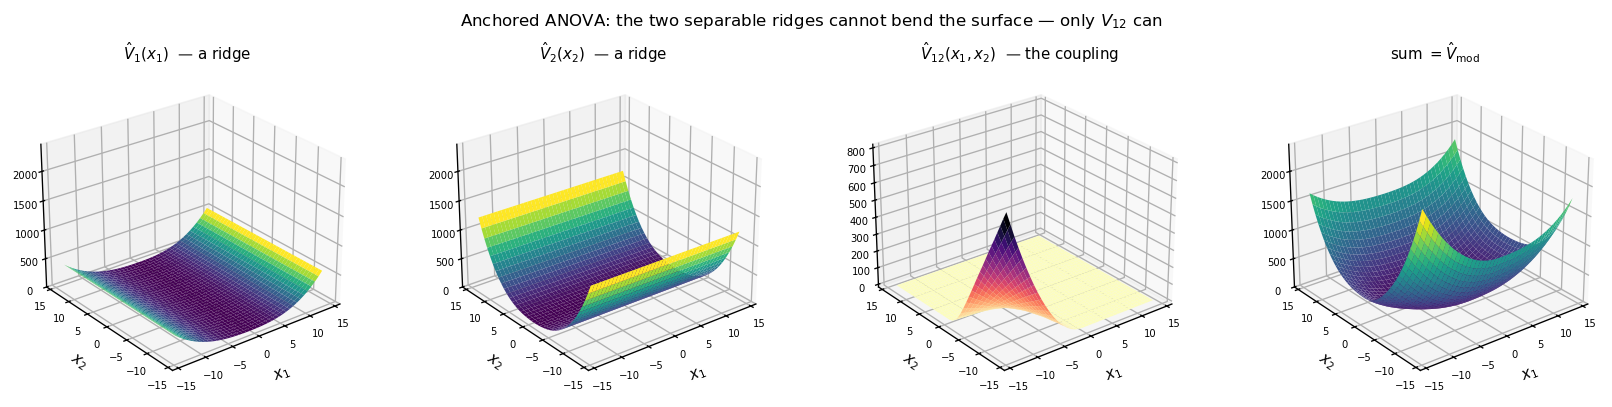

In [11]:
zmax = float(max(SMOD.max(), VSTAR.max()))
fig = plt.figure(figsize=(14, 3.4))
for j, (Z, t) in enumerate([
        (SUR1, r"$\hat V_1(x_1)$  — a ridge"),
        (SUR2, r"$\hat V_2(x_2)$  — a ridge"),
        (SUR12, r"$\hat V_{12}(x_1,x_2)$  — the coupling"),
        (SMOD, r"sum $=\hat V_{\rm mod}$")]):
    ax = fig.add_subplot(1, 4, j + 1, projection="3d")
    surf(ax, Z, t, zlim=(0, zmax) if j != 2 else None,
         cmap="magma_r" if j == 2 else "viridis")
fig.suptitle("Anchored ANOVA: the two separable ridges cannot bend the surface — "
             r"only $V_{12}$ can", fontsize=10)
fig.tight_layout()
plt.show()

Note the third panel: $\hat V_{12}$ is flat at zero over most of the plane and
rises only in the third quadrant, where both inventories are short and the
shared capacity binds. It is exactly zero along both axes — the anchor cross.

### $V^\star$ versus the two reconstructions

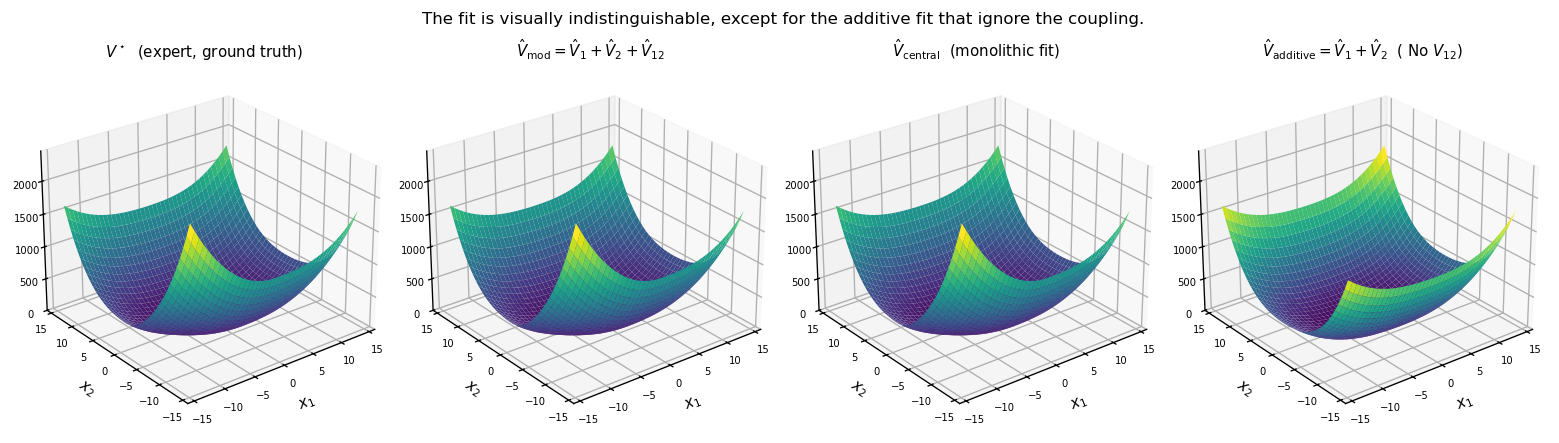

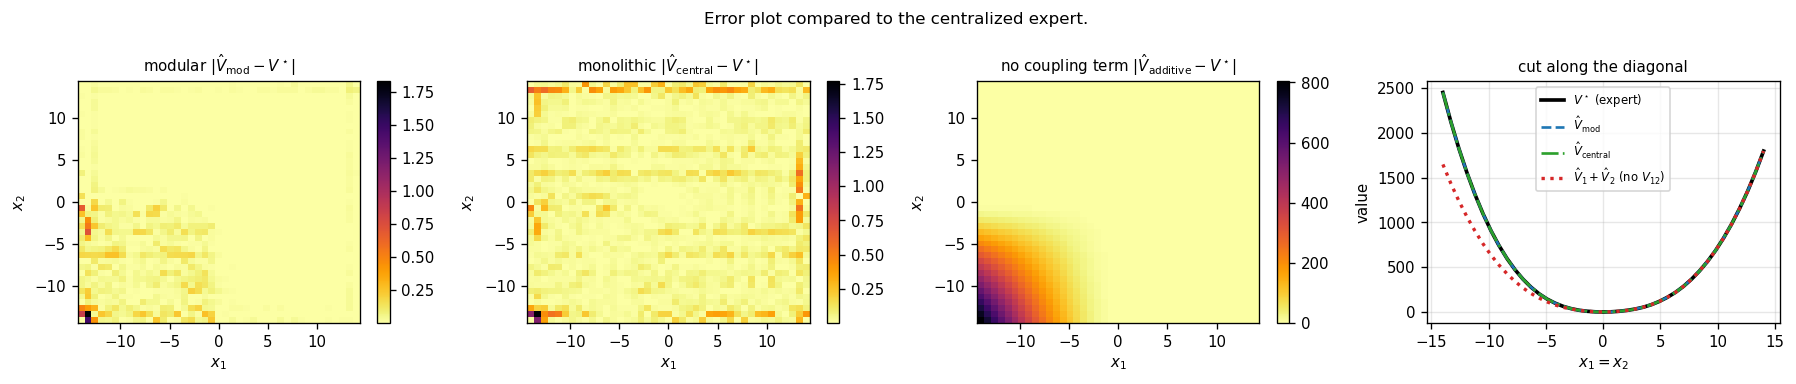

offset-relative error      median        max   median (both short)
modular                  1.89e-04   1.83e+00              4.55e-02
monolithic               2.70e-02   1.77e+00              2.33e-02
no coupling term         1.01e-07   8.03e+02              7.13e+01

On the diagonal the red curve peels away from the expert exactly in the
third quadrant (both short) - that gap IS V12, and it is what the
coordinator needs in order to split the shared capacity correctly.


In [27]:
zl = (0, float(VSTAR.max()))
fig = plt.figure(figsize=(13, 3.8))
for j, (Z, t) in enumerate([
        (VSTAR, r"$V^\star$  (expert, ground truth)"),
        (SMOD, r"$\hat V_{\rm mod}=\hat V_1+\hat V_2+\hat V_{12}$"),
        (SCEN, r"$\hat V_{\rm central}$  (monolithic fit)"),
        (SUR1+SUR2, r"$\hat V_{\rm additive}=\hat V_1+\hat V_2$  ( No $V_{12}$)")]):
    ax = fig.add_subplot(1, 4, j + 1, projection="3d")
    surf(ax, Z, t, zlim=zl)
fig.suptitle("The fit is visually indistinguishable, except for the additive fit that ignore the coupling.",
             fontsize=10)
fig.tight_layout()
plt.show()

E_MOD = np.abs(SMOD - VSTAR) # modular: V1 + V2 + V12
E_CEN = np.abs(SCEN - VSTAR) # monolithic
E_DEC = np.abs(SUR1 + SUR2 - VSTAR)   # what you get without the interaction module V12

from matplotlib.colors import LogNorm
vmin = max(1e-8, min(E_MOD[E_MOD > 0].min(), E_CEN[E_CEN > 0].min()))
vmax = max(E_MOD.max(), E_CEN.max(), E_DEC.max())
fig, ax = plt.subplots(1, 4, figsize=(15, 3.2))
for a, (E, t) in zip(ax[:3], [(E_MOD, r"modular $|\hat V_{\rm mod}-V^\star|$"),
                              (E_CEN, r"monolithic $|\hat V_{\rm central}-V^\star|$"),
                              (E_DEC, r"no coupling term $|\hat V_{\rm additive}-V^\star|$")]):
    im = a.pcolormesh(GX1, GX2, np.maximum(E, vmin), cmap="inferno_r", shading="auto")
    a.set_xlabel(r"$x_1$"); a.set_ylabel(r"$x_2$"); a.set_title(t, fontsize=9)
    plt.colorbar(im, ax=a)
fig.suptitle("Error plot compared to the centralized expert.",
             fontsize=10)

dg = np.arange(NGV)
ax[3].plot(gv, VSTAR[dg, dg], "k-", lw=2.2, label=r"$V^\star$ (expert)")
ax[3].plot(gv, SMOD[dg, dg], "--", color="tab:blue", lw=1.6, label=r"$\hat V_{\rm mod}$")
ax[3].plot(gv, SCEN[dg, dg], "-.", color="tab:green", lw=1.6, label=r"$\hat V_{\rm central}$")
ax[3].plot(gv, (SUR1 + SUR2)[dg, dg], ":", color="tab:red", lw=2.0,
           label=r"$\hat V_1+\hat V_2$ (no $V_{12}$)")
ax[3].set_xlabel(r"$x_1 = x_2$"); ax[3].set_ylabel("value")
ax[3].set_title(r"cut along the diagonal", fontsize=9)
ax[3].legend(fontsize=7)
fig.tight_layout()
plt.show()

conflict = (GX1 < 0) & (GX2 < 0)
print(f"{'offset-relative error':22s} {'median':>10s} {'max':>10s} "
      f"{'median (both short)':>21s}")
for t, E in [("modular", E_MOD), ("monolithic", E_CEN), ("no coupling term", E_DEC)]:
    print(f"{t:22s} {np.median(E):10.2e} {E.max():10.2e} {np.median(E[conflict]):21.2e}")
print("\nOn the diagonal the red curve peels away from the expert exactly in the")
print("third quadrant (both short) - that gap IS V12, and it is what the")
print("coordinator needs in order to split the shared capacity correctly.")

### Summary

The monolithic fit based on the centralized data, and the modular fit based on locally learning the modules are visually identical to the centralized expert!
The modular fit that ignores the interaction module (fouth subplot), however, looks different. That gap **is** the interaction effect $V_{12}$, and it is what the coordinator needs in order to split the shared capacity correctly.

From this we can conlude the following:

**We can reconstruct the cost-to-go of a centralized coupled MPC problem using locally learned modules + an interaction module**
This involves
1. Each agent learns independently, in **1D**, which are very easy. 
2. The interaction module $V_{12}$ is **necessary**, and must be learnt in 2D. However, since the interaction only affects when both the agents have a backlog, this only affects a portion of the state-space. In the example above, even though the state-space spans [-14,14]$^2$, the interaction module requires sampling only in a subset of the state-space [-14,0]$^2$. 

This enables modularity, interpretability, and scalability. 
